In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import astropy.units as units
import astropy.constants as const
from scipy.special import wofz
from tqdm import tqdm
from rtfunctions import one_full_fs, sc_2nd_order, calc_lambda_full, calc_lambda_monoc
import time
import illuminated_finite_slab as ill

In [2]:
def plot_line_and_composite(lines, slab, S_nu_grid, I_emergent):
    """Plot per-line emissivities, per-line S_line vs tau, composite S_nu and improved contribution diagnostics."""
    x = slab.x_values
    tau = slab.tau
    B = slab.B
    # ensure x_weights exist
    if getattr(slab, 'x_weights', None) is None:
        dx = x[1] - x[0] if x.size > 1 else 1.0
        slab.x_weights = np.ones_like(x) * dx

    # ensure per-line normalized profile present (use slab.x_weights)
    for line in lines:
        if not hasattr(line, 'phi_x_global') or line.phi_x_global.size != x.size:
            # compute or re-map profile to global x grid if needed
            if hasattr(line, 'compute_phi_x'):
                line.compute_phi_x(x)
            else:
                # fallback: assume phi_x already present on x
                line.phi_x = getattr(line, 'phi_x', np.zeros_like(x))
            # normalize with slab.x_weights
            norm = np.sum(line.phi_x * slab.x_weights)
            line.phi_x_global = (line.phi_x / norm) if norm != 0.0 else line.phi_x.copy()

    # diagnostic: print phi normalization for each line
    for i, line in enumerate(lines):
        s = np.sum(line.phi_x_global * slab.x_weights)
        print(f"Line {i+1} phi normalization (sum phi*xw): {s:.6g}")

    # Build per-line emissivity arrays eta_i(depth, x) = k * phi_x_global * S_line(depth)
    Nfreq = x.size
    ND = slab.ND
    eta_list = []
    for line in lines:
        Svec = np.asarray(line.S_line).reshape((ND, 1))
        eta = (line.k * line.phi_x_global)[None, :] * Svec  # shape (ND, Nfreq)
        eta_list.append(eta)

    # Recreate original denom-based contribution used previously:
    denom = np.zeros_like(x)
    for line in lines:
        denom += line.k * line.phi_x_global
    denom_safe = np.where(denom == 0.0, 1.0, denom)

    # contribution(depth,x) = (k * phi(x) * S_line(depth)) / denom(x)
    contribs = []
    for i, line in enumerate(lines):
        contrib = eta_list[i] / denom_safe[None, :]
        contribs.append(contrib)

    # 1) For each line: emissivity vs x at selected depths, and S_line vs tau with Planck B
    depths_idx = [0, ND // 2, ND - 1]  # top, mid, bottom
    for i, line in enumerate(lines):
        plt.figure(figsize=(8,4))
        for d in depths_idx:
            emiss = eta_list[i][d, :]
            plt.plot(x, emiss, label=f'depth idx {d}')
        plt.plot(x, S_nu_grid[depths_idx[1], :] * (line.k * np.max(line.phi_x_global)), ':k', label='Composite S (mid) scaled')
        plt.xlabel('x (Doppler units)')
        plt.ylabel('Emissivity (arbitrary units)')
        plt.title(f'Line {i+1} emissivity vs x (selected depths) — center={line.line_center}')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f'line_{i+1}_emissivity_vs_x.png', dpi=150)
        plt.close()

        # S_line vs tau with Planck B reference
        plt.figure(figsize=(6,4))
        plt.plot(tau, line.S_line, label=f'Line {i+1} S_line')
        if np.size(B) == ND:
            plt.plot(tau, B, ':k', label='Planck B (depth)')
        else:
            plt.plot(tau, np.mean(B) * np.ones_like(tau), ':k', label='Planck B (mean)')
        plt.xscale('log')
        plt.xlabel('Optical depth (tau)')
        plt.ylabel('Source function')
        plt.title(f'Line {i+1} Source function vs tau')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f'line_{i+1}_S_vs_tau.png', dpi=150)
        plt.close()

    # 2) Composite source: S_nu vs x for selected depths, with Planck B
    plt.figure(figsize=(8,4))
    for d in depths_idx:
        plt.plot(x, S_nu_grid[d, :], label=f'Composite S at depth idx {d}')
    plt.plot(x, np.mean(B) * np.ones_like(x), ':k', label='Planck B (mean)')
    plt.xlabel('x (Doppler units)')
    plt.ylabel('Composite source S_nu (depth slice)')
    plt.title('Composite Source Function vs x (selected depths)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('composite_S_vs_x_selected_depths.png', dpi=150)
    plt.close()

    # 3) Composite S heatmap with contribution contours (denom-based)
    plt.figure(figsize=(10, 6))
    im = plt.imshow(S_nu_grid, aspect='auto', origin='lower', extent=[x[0], x[-1], tau[0], tau[-1]], cmap='plasma')
    cbar = plt.colorbar(im, label='Composite S_nu(depth, x)')
    palette = ['cyan', 'lime', 'maroon', 'magenta', 'yellow', 'orange']
    contour_levels = [0.25, 0.5]
    from matplotlib.lines import Line2D
    legend_handles = []
    for idx, contrib in enumerate(contribs):
        color = palette[idx % len(palette)]
        try:
            CS = plt.contour(x, tau, contrib, levels=contour_levels, colors=[color], linewidths=1.2)
        except Exception:
            plt.contourf(x, tau, contrib, levels=[0.0] + contour_levels, colors=[color], alpha=0.05)
        legend_handles.append(Line2D([0], [0], color=color, lw=2, label=f'Line {idx+1} contrib'))
    plt.xlabel('x (Doppler units)')
    plt.ylabel('Optical depth (tau)')
    plt.title('Composite S_nu (heatmap) with line contribution contours')
    heatmap_proxy = Line2D([0], [0], color='k', lw=2, linestyle='--', label='Composite S (heatmap)')
    all_handles = [heatmap_proxy] + legend_handles
    plt.legend(handles=all_handles, loc='upper right')
    plt.tight_layout()
    plt.savefig('combined_line_contributions_depth_x.png', dpi=150)
    plt.close()

    # 4) Per-line contributions vs x for ALL depths (decimated curves to avoid overplotting)
    plt.figure(figsize=(11,6))
    decim = max(1, int(np.ceil(slab.ND / 60)))  # plot up to ~60 depth curves
    depths_all = np.arange(0, slab.ND, decim)
    for idx, contrib in enumerate(contribs):
        color = palette[idx % len(palette)]
        # plot many depth slices with low alpha
        for d in depths_all:
            plt.plot(x, contrib[d, :], color=color, alpha=0.08, linewidth=1)
        # overlay a thicker mean contribution curve for visibility
        mean_curve = np.mean(contrib[depths_all, :], axis=0)
        plt.plot(x, mean_curve, color=color, lw=1.5, alpha=0.9, label=f'Line @{lines[idx].line_center} contribution (avg depths)')

        # find depth where this line contributes the most (integrated over x with weights)
        if getattr(slab, "x_weights", None) is None:
            dx = x[1] - x[0]
            xw = np.ones_like(x) * dx
        else:
            xw = slab.x_weights
        # total fractional contribution per depth (weighted integral over x)
        total_per_depth = np.sum(contrib * xw[None, :], axis=1)
        depth_max = int(np.argmax(total_per_depth))
        # plot the contribution curve at that depth as a thick line
        plt.plot(x, contrib[depth_max, :], color=color, lw=2.5, alpha=1.0, linestyle = "--",
                 label=f'Line @{lines[idx].line_center} peak depth idx={depth_max}, tau={slab.tau[depth_max]:.2g}')

    # overlay composite S (choose mid depth) as dashed black curve for comparison
    mid = slab.ND // 2
    plt.plot(x, S_nu_grid[mid, :], '--k', lw=2.0, label='Composite S (mid depth)')
    # overlay Planck B reference (mean)
    plt.plot(x, np.mean(B) * np.ones_like(x), ':k', label='Planck B (mean)')
    plt.xlabel('x (Doppler units)')
    plt.ylabel('Per-line contribution to composite S')
    plt.title('Per-line contributions vs x (all depths overlay; avg & mid shown)')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig('per_line_contributions_all_depths_vs_x.png', dpi=150)
    plt.close()

    print("Saved plots: per-line emissivity, S_vs_tau, composite S vs x/tau, combined contribution heatmap, and per-line contributions (all depths).")

<h2>Playground for 2 components</h2>
<p>Testing out the illuminated finite slab module. So far it works for a single component, but we are now trying to extend it to two components. We want to produce the He I 1083 nm line profile.</p>

In [3]:
# Let's create a slab first
ND = 51
tau_max = 1e3
epsilon = np.ones(ND) * 5e-3
B = np.ones(ND) * 5.0

slab = ill.Slab(ND, tau_max, epsilon, B, H=70000.0)

In [4]:
# Calculate the scattered J
slab.calculate_J_scat()

Converged after 57 iterations.


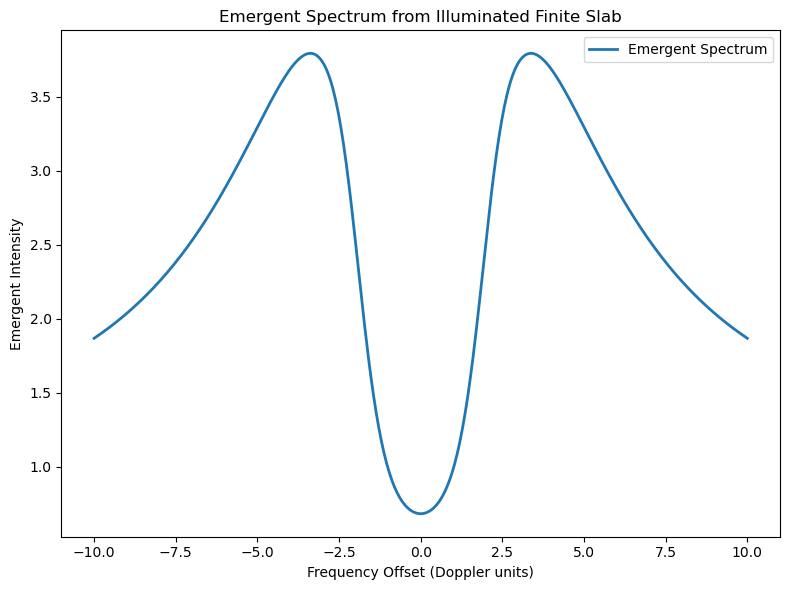

In [5]:
# First, solve for one component
slab.solve_source_function_ALO(max_iter=500, tol=1e-6)
S_alo = slab.S

# Second, create an observed spectrum
x_obs = np.linspace(-10, 10, 501)  # Frequency grid
slab.a = 0.1 # Set damping parameter
spectrum = slab.formal_solution_given_direction(mu_obs=1.0, x_obs=x_obs, boundary_condition=1.0, recalc_profile=True)

slab.solve_source_function()
S_direct = slab.S

# Plot the results
plt.figure(figsize=(8,6))
plt.plot(x_obs, spectrum, linewidth = 2, label="Emergent Spectrum")
plt.xlabel("Frequency Offset (Doppler units)")
plt.ylabel("Emergent Intensity")
plt.title("Emergent Spectrum from Illuminated Finite Slab")
plt.legend()
plt.tight_layout()

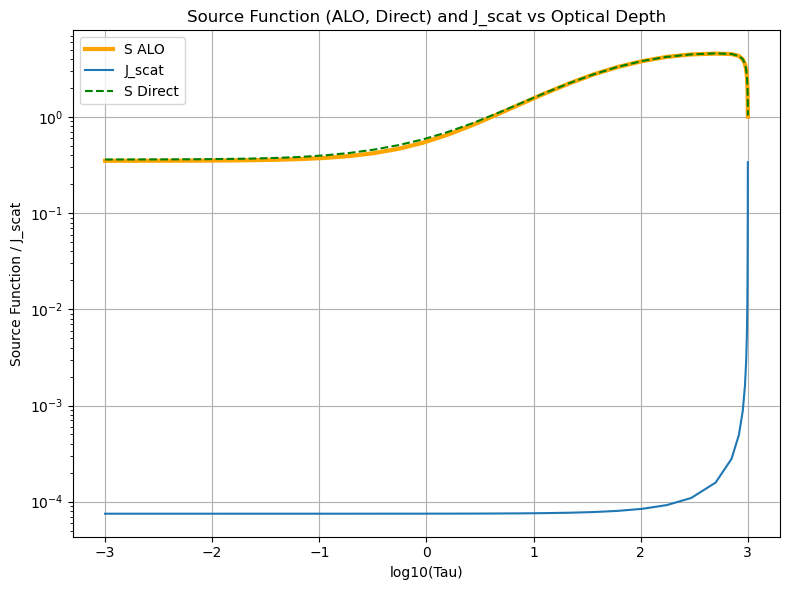

In [6]:
plt.figure(figsize=(8,6))
plt.semilogy(np.log10(slab.tau),S_alo, linestyle = "-", linewidth = 3, color = "orange", label="S ALO")
plt.semilogy(np.log10(slab.tau),slab.J_scat, label="J_scat")
plt.semilogy(np.log10(slab.tau),S_direct, linestyle = "--", color = "green", alpha = 1.0, label="S Direct")
#plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("log10(Tau)")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function (ALO, Direct) and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

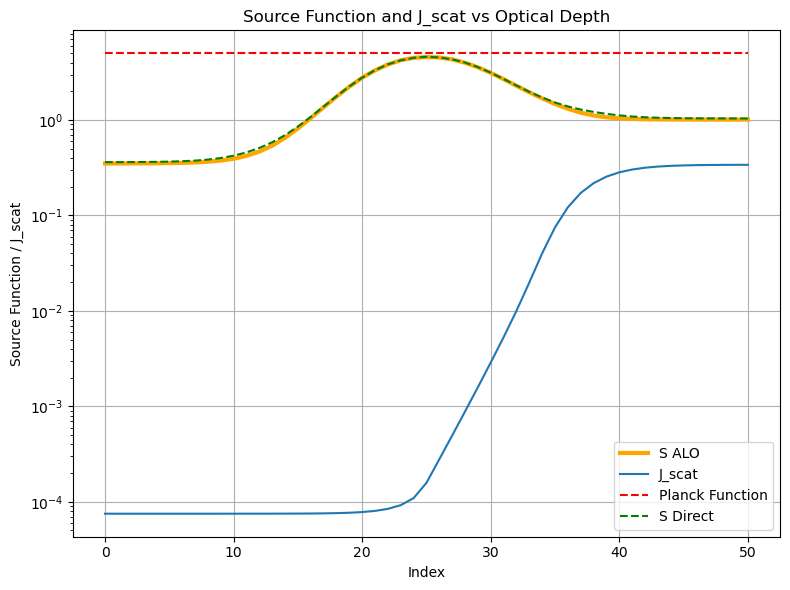

In [7]:
# Other variant where we use the depth index to plot all the variables
plt.figure(figsize=(8,6))
plt.semilogy(S_alo, linestyle = "-", linewidth = 3, color = "orange", label="S ALO")
plt.semilogy(slab.J_scat, label="J_scat")
plt.semilogy(slab.B, linestyle = "--", color = "red", alpha = 1.0, label="Planck Function")
plt.semilogy(S_direct, linestyle = "--", color = "green", alpha = 1.0, label="S Direct")
#plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("Index")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

<h3>So far, so good...</h3>
<p>This is within the expectacions and in accordance with literature.</p>
<h3>But what about two components?</h3>
<p>The next step is to define two-component profiles in the same slab. The idea is to have two different sets of parameters for the two components, and then combine their contributions to get the final profile.</p>
<p>We will need to define parameters such as optical depth, Doppler width, and source function for each component separately. Then, we can compute the emergent intensity by summing the contributions from both components.</p>
<p>Let's implement this and see how the resulting profile looks compared to the single-component case.</p>

In [8]:
slab2 = ill.Slab(ND, tau_max, epsilon, B, H=10e6) # Note height in m

<p>After some consideration, we have decided to use Lambda iteration instead of ALI for the initial attempt to model two components. This approach will me slightly slower, but it will be easier to write. </p>
<p> Absorption WIP </p>

In [9]:
# Second, create an observed spectrum
x_obs = np.linspace(-10, 10, 501)  # Frequency grid
slab.a = 0.1 # Set damping parameter
spectrum = slab2.formal_solution_given_direction(mu_obs=1.0, x_obs=x_obs, boundary_condition=1.0, recalc_profile=True)

slab2.calculate_J_scat()

slab2.solve_source_function_LI_2comp()
S_LI = slab2.S

In [10]:
print(np.shape(slab2.J_scat))
print(np.shape(slab2.phi))

(51,)
(41,)


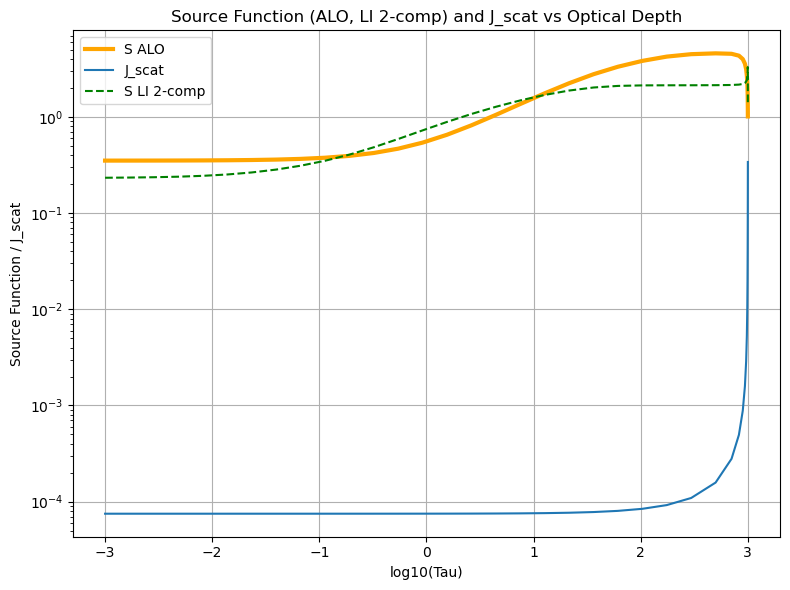

In [11]:
plt.figure(figsize=(8,6))
plt.semilogy(np.log10(slab.tau),S_alo, linestyle = "-", linewidth = 3, color = "orange", label="S ALO")
plt.semilogy(np.log10(slab.tau),slab.J_scat, label="J_scat")
plt.semilogy(np.log10(slab.tau),S_LI, linestyle = "--", color = "green", alpha = 1.0, label="S LI 2-comp")
#plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("log10(Tau)")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function (ALO, LI 2-comp) and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

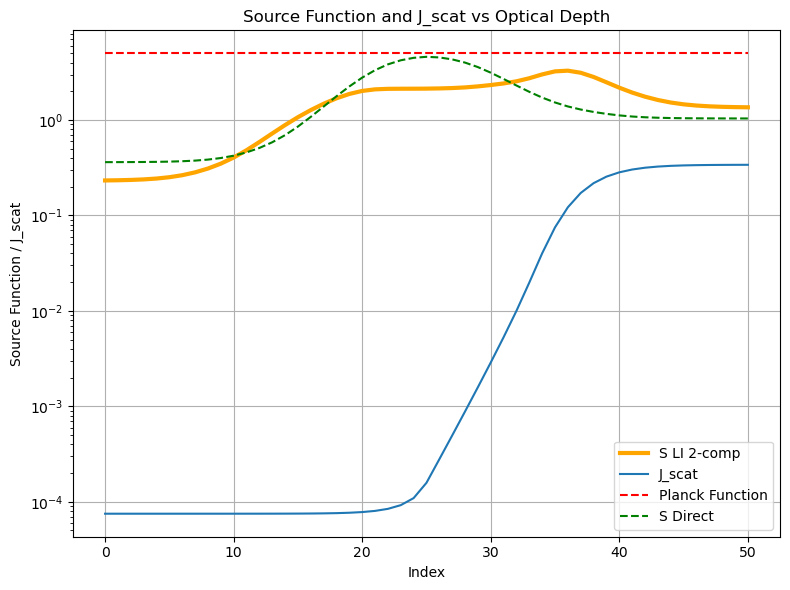

In [12]:
 # Other variant where we use the depth index to plot all the variables
plt.figure(figsize=(8,6))
plt.semilogy(S_LI, linestyle = "-", linewidth = 3, color = "orange", label="S LI 2-comp")
plt.semilogy(slab.J_scat, label="J_scat")
plt.semilogy(slab.B, linestyle = "--", color = "red", alpha = 1.0, label="Planck Function")
plt.semilogy(S_direct, linestyle = "--", color = "green", alpha = 1.0, label="S Direct")
# plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("Index")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

<h2>28. 01. 2026.</h2>
<p> The approach showed above needs refinement. </p>

In [13]:
slab3 = ill.Slab(ND, tau_max, epsilon, B, H=10e6) # Note height in m

# Second, create an observed spectrum
x_obs = np.linspace(-10, 10, 501)  # Frequency grid
slab3.a = 0.1 # Set damping parameter
spectrum = slab3.formal_solution_given_direction(mu_obs=1.0, x_obs=x_obs, boundary_condition=1.0, recalc_profile=True)

slab3.calculate_J_scat()

slab3.composite_source()
S_composite = slab3.S

TypeError: Slab.Line.__init__() got an unexpected keyword argument 'd_lamb'

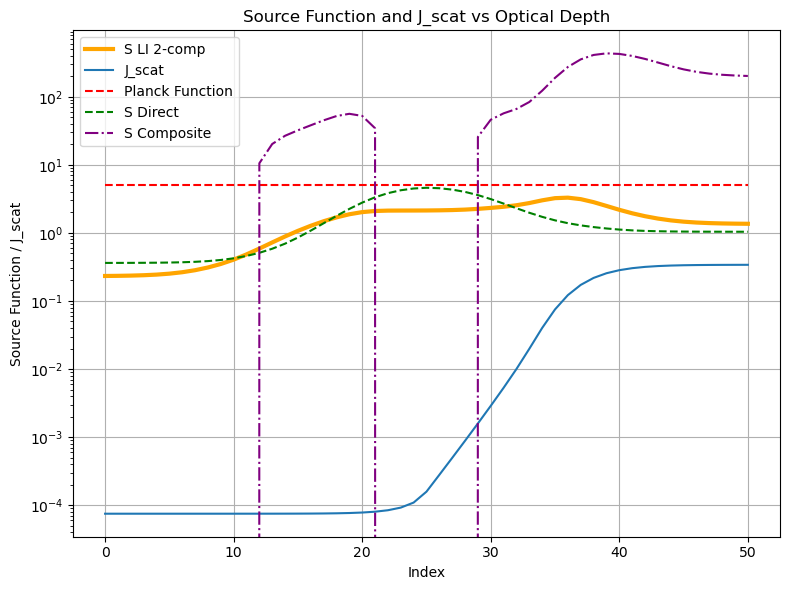

In [ ]:
plt.figure(figsize=(8,6))
plt.semilogy(S_LI, linestyle = "-", linewidth = 3, color = "orange", label="S LI 2-comp")
plt.semilogy(slab.J_scat, label="J_scat")
plt.semilogy(slab.B, linestyle = "--", color = "red", alpha = 1.0, label="Planck Function")
plt.semilogy(S_direct, linestyle = "--", color = "green", alpha = 1.0, label="S Direct")
plt.semilogy(S_composite, linestyle = "-.", color = "purple", alpha = 1.0, label="S Composite")
# plt.plot(np.log10(slab.tau),S_direct, linestyle = "-.", color = "blue", alpha = 0.5, label="S, ALO solved")
plt.xlabel("Index")
plt.ylabel("Source Function / J_scat")
plt.title("Source Function and J_scat vs Optical Depth")
plt.legend()
plt.grid()
plt.tight_layout()

[-123.28239429 -122.11154096 -120.17490317 -117.01593893 -111.98337515
 -104.26530432  -93.10768012  -78.29512787  -60.60511651  -41.44677716
  -21.98755842   -3.83730455   10.53390355   20.21828589   26.7079651
   32.15049664   38.07782172   45.01123802   52.02921505   56.16135521
   52.27045765   34.49287932   -0.58271495  -49.24109782  -95.41259817
 -113.90672329  -93.96951719  -51.76141992   -7.69317766   25.66359818
   45.96023947   57.04711393   66.15778866   83.69962954  122.65601109
  189.37391919  273.55322064  353.9708589   410.91625204  433.83916821
  425.64342273  397.62732796  359.38247532  318.32393399  281.33676347
  252.44508252  232.07917609  218.66313689  210.19351622  204.98412002
  201.82854234]


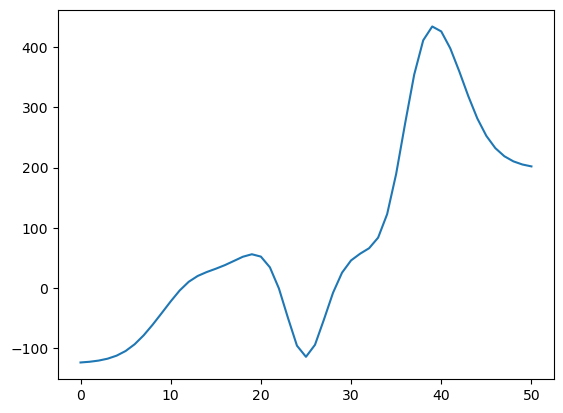

In [ ]:
print(S_composite)
plt.plot(S_composite)

<h2>19. 02. 2026.</h2>
<p>A short presentation of some new results.</p>

In [14]:
import SLab_linev2 as v2

# Create a slab
# Define the input parameters
ND = 81
tau_max = 1e3
epsilon = np.ones(ND) * 5e-3
B = np.ones(ND) * 5.0
H = 80000.0 # Height of the slab above the solar surface in kilometers
slab = v2.Slab(ND, tau_max, epsilon, B, H)

# And lines
line1 = v2.Slab.Line(81, line_center=0.0, a=0.1, k=1.0, slab_in=slab)  # Example line, we will need to pass the slab instance to the line   
line2 = v2.Slab.Line(81, line_center=3.2, a=0.2, k=8.0, slab_in=slab)  # Another example line
line3 = v2.Slab.Line(81, line_center=8.5, a= 0.5, k=3.0, slab_in=slab)

In [15]:
# Create a list of lines and pass it to the slab
lines = [line1, line2, line3]

# Now we can calculate the source function for each line
slab.global_x_grid(lines)
line1.compute_S_line(max_iter=1000, tol=1e-6, global_x_grid=slab.x_values)
line2.compute_S_line(max_iter=1000, tol=1e-6, global_x_grid=slab.x_values)
line3.compute_S_line(max_iter=1000, tol=1e-6, global_x_grid=slab.x_values)

  0%|          | 0/1000 [00:00<?, ?it/s]

  6%|▌         | 56/1000 [00:01<00:21, 44.68it/s]


Convergence achieved after 56 iterations with max dS = 9.26e-07


  5%|▌         | 50/1000 [00:01<00:20, 47.16it/s]


Convergence achieved after 50 iterations with max dS = 8.50e-07


  5%|▌         | 50/1000 [00:01<00:19, 47.54it/s]

Convergence achieved after 50 iterations with max dS = 8.22e-07


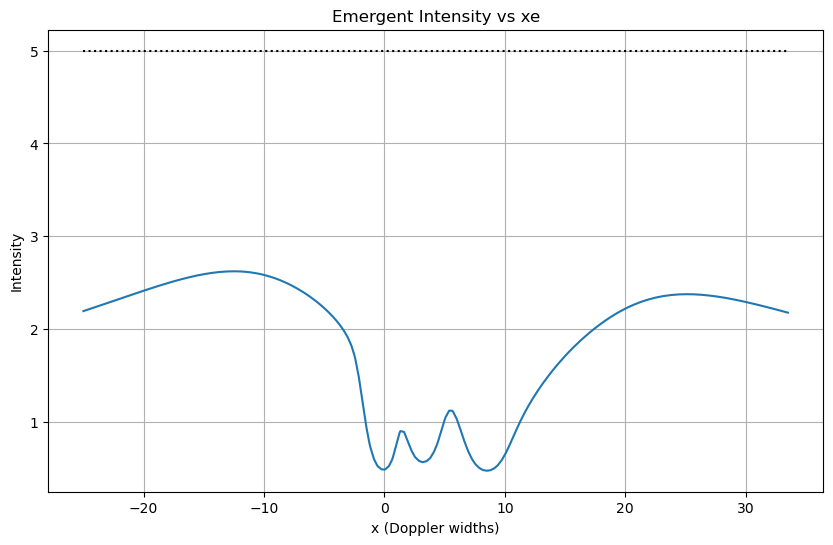

In [16]:
 # Compute the source function for each line
S = slab.formal_solution(lines, mu = 1.0, boundary_condition = 1.0)
# Plot the intensity
plt.figure(figsize=(10, 6))
plt.plot(slab.x_values, S, label='Intensity')
# Plot Planck function B (use mean if B is depth-dependent) as reference
plt.plot(slab.x_values, np.mean(slab.B) * np.ones_like(slab.x_values), ':k', label='Planck B')
plt.xlabel('x (Doppler widths)')
plt.ylabel('Intensity')
plt.title('Emergent Intensity vs xe')
plt.grid()
plt.savefig('intensity_vs_x_k1_'+str(line1.k)+'_k2_'+str(line2.k)+'.png')

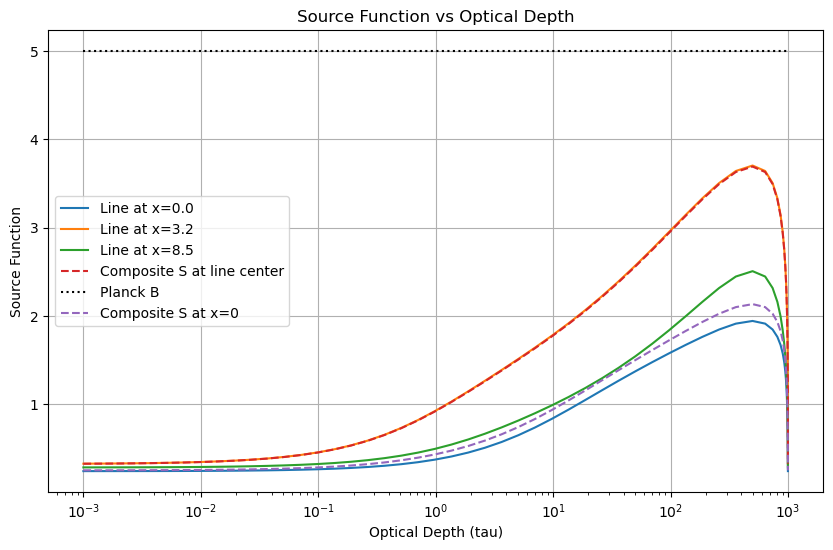

In [17]:
 # Plot the source function of each line and composite source function
plt.figure(figsize=(10, 6))
for line in lines:
    if hasattr(line, "S_line"):
        plt.plot(slab.tau, line.S_line, label=f'Line at x={line.line_center}')
composite_S = slab.composite_S(lines)
plt.plot(slab.tau, composite_S[:, slab.x_values.size//2], label='Composite S at line center', linestyle='--')
plt.plot(slab.tau, slab.B, ':k', label = 'Planck B')
center_idx = np.argmin(np.abs(slab.x_values - 0.0))
plt.plot(slab.tau, composite_S[:, center_idx], label='Composite S at x=0', linestyle='--')
plt.xlabel('Optical Depth (tau)')
plt.ylabel('Source Function')
plt.title('Source Function vs Optical Depth')
plt.xscale('log')
plt.grid()
plt.legend()
plt.savefig('source_function_vs_tau_k1_'+str(line1.k)+'_k2_'+str(line2.k)+'.png')

In [18]:
 # Build composite source function grid (depth x frequency)
S_nu_grid = slab.composite_S(lines)   # shape (ND, Nfreq)

# Compute emergent intensity (formal solution) and store in slab.I
I_emergent = slab.formal_solution(lines, mu = 1.0, boundary_condition = 1.0)

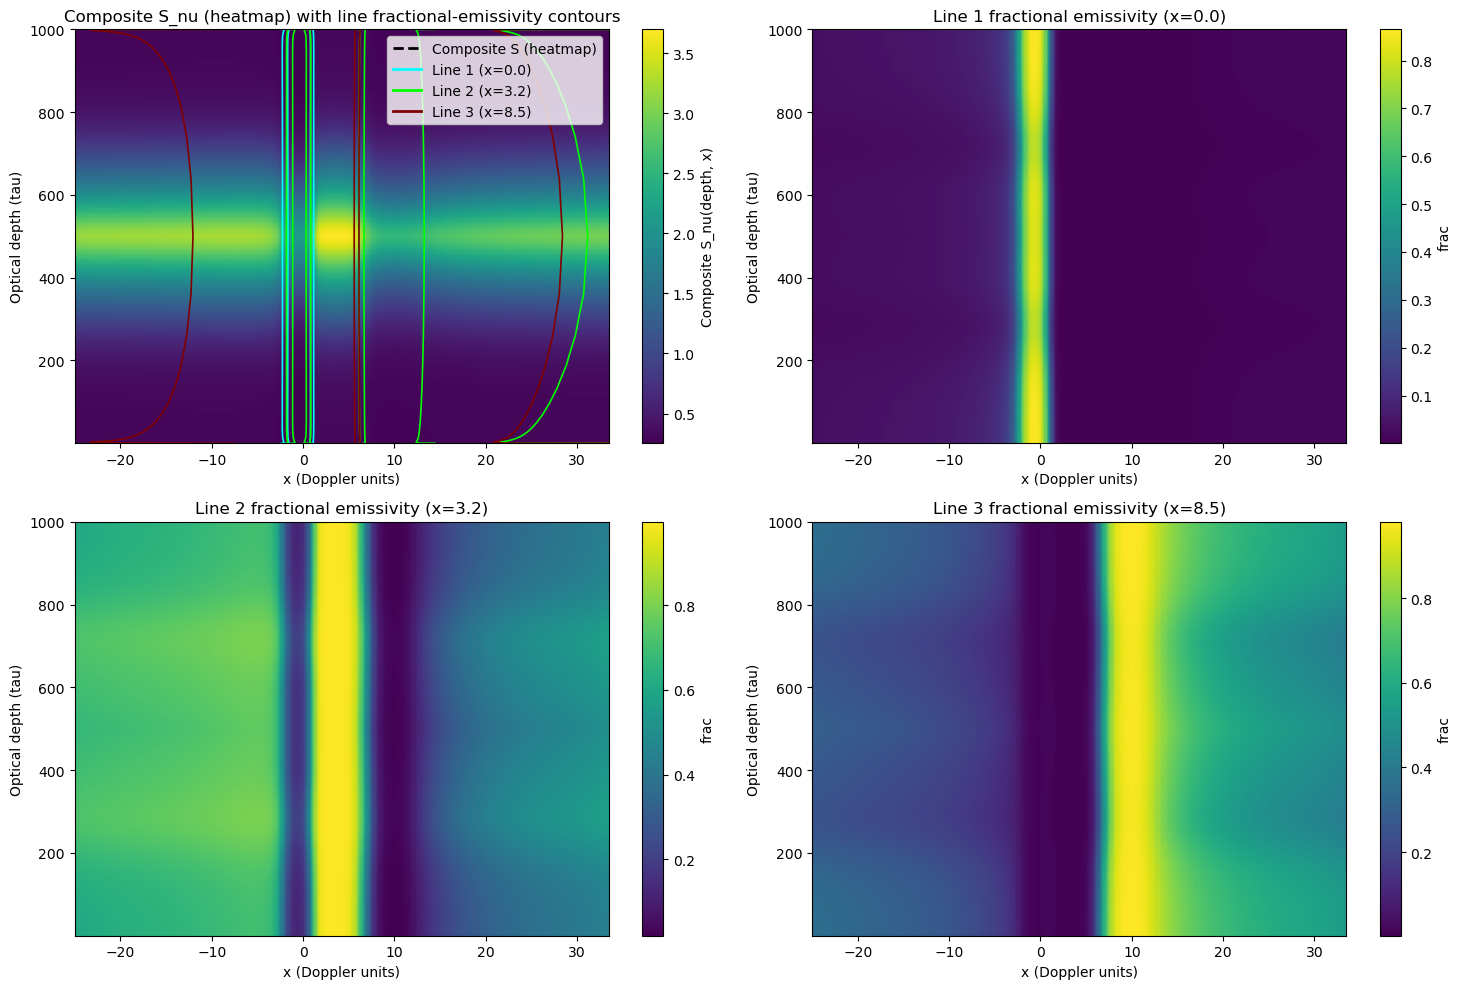

In [19]:
# Combined plot: Composite S_nu heatmap with contours + subplots for each line's contribution
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

x = slab.x_values
tau = slab.tau
B = slab.B

# Ensure phi_x_global exists and normalized
for line in lines:
    if not hasattr(line, 'phi_x_global') or line.phi_x_global.size != x.size:
        if hasattr(line, 'compute_phi_x'):
            line.compute_phi_x(x)
        norm = np.sum(line.phi_x * slab.x_weights) if getattr(slab, 'x_weights', None) is not None else np.sum(line.phi_x)
        line.phi_x_global = (line.phi_x / norm) if norm != 0.0 else line.phi_x.copy()

# Build per-line emissivity arrays (depth x frequency): eta = k * phi * S_line
eta_list = []
for line in lines:
    eta = (line.k * line.phi_x_global)[None, :] * np.asarray(line.S_line).reshape((slab.ND, 1))
    eta_list.append(eta)
total_eta = np.sum(np.array(eta_list), axis=0)
total_eta_safe = np.where(total_eta == 0.0, 1.0, total_eta)
contribs = [eta / total_eta_safe for eta in eta_list]  # fractional emissivity per line

# Create figure with subplots: heatmap + individual contribution panels
fig = plt.figure(figsize=(15, 10))
ax_main = plt.subplot(2, 2, 1)
im = ax_main.imshow(S_nu_grid, aspect='auto', origin='lower', extent=[x[0], x[-1], tau[0], tau[-1]], cmap='viridis')
cbar = plt.colorbar(im, ax=ax_main, label='Composite S_nu(depth, x)')
palette = ['cyan', 'lime', 'maroon', 'magenta', 'yellow', 'orange']
contour_levels = [0.25, 0.5]
legend_handles = []
for idx, frac in enumerate(contribs):
    color = palette[idx % len(palette)]
    try:
        cs = ax_main.contour(x, tau, frac, levels=contour_levels, colors=color, linewidths=1.2)
    except Exception:
        ax_main.contourf(x, tau, frac, levels=[0.0] + contour_levels, colors=[color], alpha=0.05)
    legend_handles.append(Line2D([0], [0], color=color, lw=2, label=f'Line {idx+1} (x={lines[idx].line_center})'))
ax_main.set_xlabel('x (Doppler units)')
ax_main.set_ylabel('Optical depth (tau)')
ax_main.set_title('Composite S_nu (heatmap) with line fractional-emissivity contours')
heatmap_proxy = Line2D([0], [0], color='k', lw=2, linestyle='--', label='Composite S (heatmap)')
ax_main.legend(handles=[heatmap_proxy] + legend_handles, loc='upper right')

# Subplots for each line: show fractional emissivity heatmap
for idx in range(len(contribs)):
    ax = plt.subplot(2, 2, idx + 2)
    im2 = ax.imshow(contribs[idx], aspect='auto', origin='lower', extent=[x[0], x[-1], tau[0], tau[-1]], cmap='viridis')
    ax.set_title(f'Line {idx+1} fractional emissivity (x={lines[idx].line_center})')
    ax.set_xlabel('x (Doppler units)')
    ax.set_ylabel('Optical depth (tau)')
    plt.colorbar(im2, ax=ax, label='frac')

plt.tight_layout()
plt.show()

In [20]:
plot_line_and_composite(lines, slab, S_nu_grid, I_emergent)

Line 1 phi normalization (sum phi*xw): 1
Line 2 phi normalization (sum phi*xw): 1
Line 3 phi normalization (sum phi*xw): 1
Saved plots: per-line emissivity, S_vs_tau, composite S vs x/tau, combined contribution heatmap, and per-line contributions (all depths).


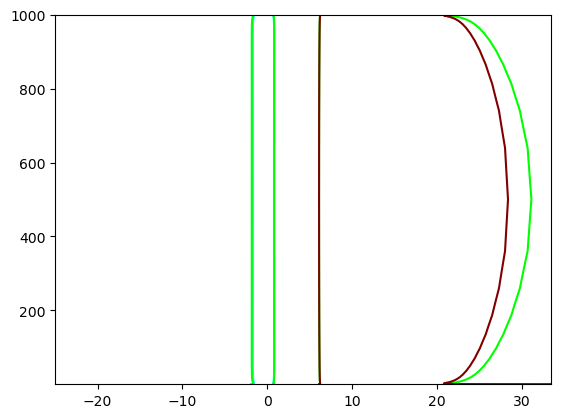

In [21]:
# Interactive 3D Surface Plot of Composite S_nu with Contours for Line Contributions
# Uses Plotly for rotation and contours on the surface to highlight contributions.
# Note: Install plotly if not present (pip install plotly).

import plotly.graph_objects as go
import numpy as np
import matplotlib.pyplot as plt  # Needed for contour extraction

# Assuming S_nu_grid, x, tau, contribs are defined from previous cells
# If not, uncomment and run setup:
# x = slab.x_values
# tau = slab.tau
# S_nu_grid = slab.composite_S(lines)
# # And contribs as before

# Create meshgrid
X, T = np.meshgrid(x, tau)

# Create the 3D surface plot
fig = go.Figure()

# Add the main surface
fig.add_trace(go.Surface(
    x=X, y=T, z=S_nu_grid,
    colorscale='Viridis',
    name='Composite S_nu',
    showscale=True,
    colorbar=dict(title='Composite S_nu')
))

# Add contours for each line's contribution on the surface
# We'll project the contours by adding them as lines on the surface
palette = ['cyan', 'lime', 'maroon', 'magenta', 'yellow', 'orange']
for idx, contrib in enumerate(contribs):
    # Add contour lines at a specific level (e.g., 0.1) projected on the surface
    levels = [0.5]  # Adjust levels as needed
    cs = plt.contour(X, T, contrib, levels=levels, colors=palette[idx % len(palette)])
    # Extract paths from contour
    for level_idx, segs in enumerate(cs.allsegs):
        for path in segs:
            verts = path  # path is already a numpy array of shape (n, 2)
            x_verts = verts[:, 0]
            y_verts = verts[:, 1]
            # Interpolate z from S_nu_grid at these points (approximate using mid-depth)
            z_interp = np.interp(x_verts, x, S_nu_grid[len(tau)//2, :])
            fig.add_trace(go.Scatter3d(
                x=x_verts, y=y_verts, z=z_interp,
                mode='lines',
                line=dict(color=palette[idx % len(palette)], width=4),
                name=f'Line {idx+1} Contrib > {levels[level_idx]}',
                showlegend=True
            ))

# Update layout for better viewing
fig.update_layout(
    title='Interactive 3D Surface of Composite S_nu with Line Contribution Contours',
    scene=dict(
        xaxis_title='x (Doppler units)',
        yaxis_title='Optical Depth (tau)',
        zaxis_title='Source Function S_nu',
        camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))  # Initial view
    ),
    width=800, height=600
)

# Show the interactive plot
fig.show()

In [42]:
ND = 81
tau_max = 1e1
epsilon = np.ones(ND) * 5e-4
B = np.ones(ND) * 1.0
H = 80000.0 # Height of the slab above the solar surface in kilometers
slab = v2.Slab(ND, tau_max, epsilon, B, H)

# And lines
line1 = v2.Slab.Line(81, line_center=0.0, a=0.1, k=1.0, slab_in=slab)  # Example line, we will need to pass the slab instance to the line   
line2 = v2.Slab.Line(81, line_center=3.2, a=0.2, k=8.0, slab_in=slab)  # Another example line
line3 = v2.Slab.Line(81, line_center=8.5, a= 0.5, k=12.0, slab_in=slab)

In [43]:
lines = [line1, line2, line3]

# Now we can calculate the source function for each line
slab.global_x_grid(lines)
line1.compute_S_line(max_iter=1000, tol=1e-6, global_x_grid=slab.x_values)
line2.compute_S_line(max_iter=1000, tol=1e-6, global_x_grid=slab.x_values)
line3.compute_S_line(max_iter=1000, tol=1e-6, global_x_grid=slab.x_values)

  4%|▍         | 42/1000 [00:00<00:22, 42.87it/s]


Convergence achieved after 42 iterations with max dS = 7.60e-07


  6%|▋         | 63/1000 [00:01<00:21, 43.48it/s]


Convergence achieved after 63 iterations with max dS = 9.22e-07


  5%|▌         | 54/1000 [00:01<00:21, 43.25it/s]

Convergence achieved after 54 iterations with max dS = 9.26e-07


 12%|█▏        | 239/2000 [00:09<01:09, 25.30it/s]


Line 1 phi normalization (sum phi*xw): 1
Line 2 phi normalization (sum phi*xw): 1
Line 3 phi normalization (sum phi*xw): 1


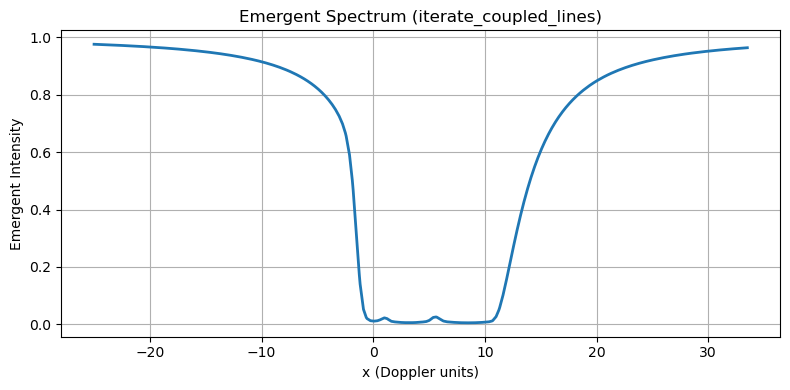

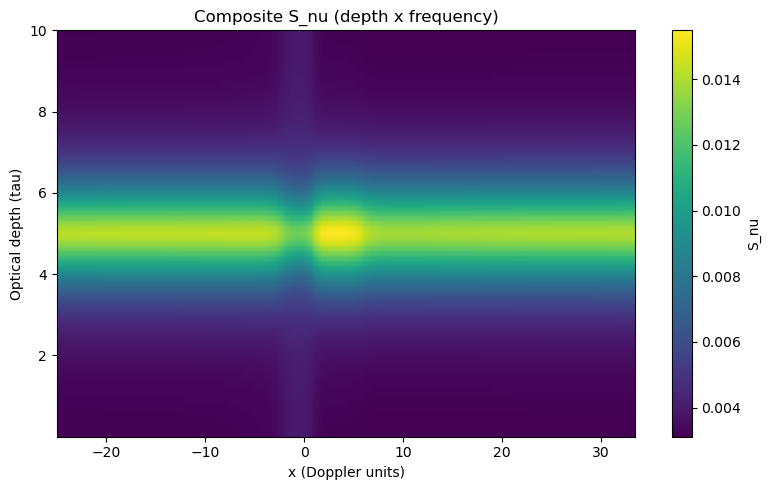

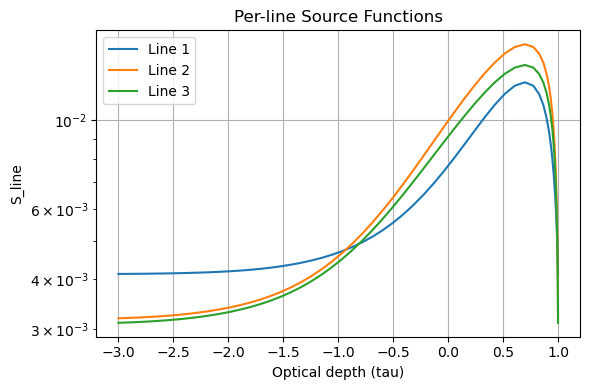

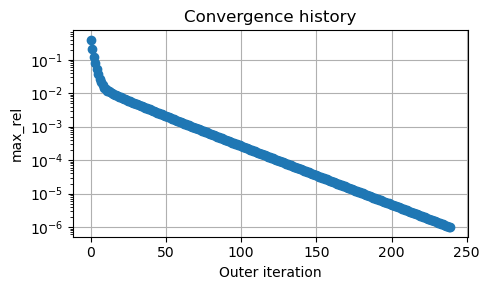

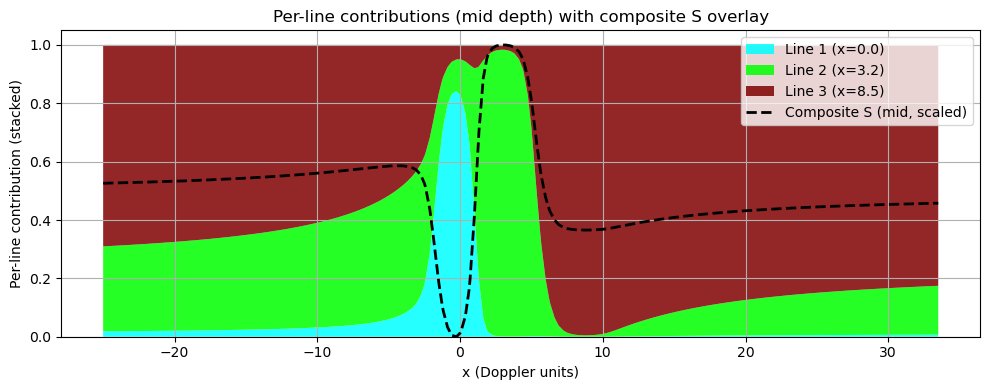

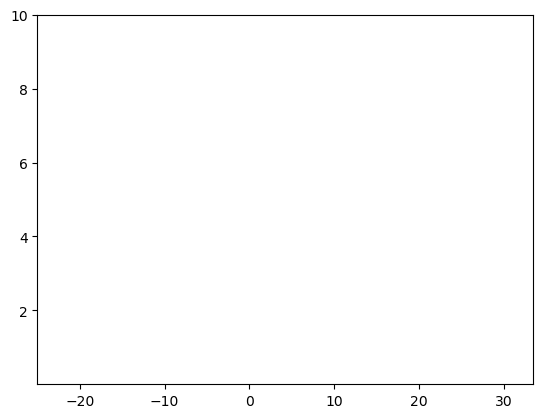

In [44]:
result = slab.iterate_coupled_lines(lines, max_iter=2000, tol=1e-6, verbose=False)

S_nu = result["S_nu"]            # shape (ND, Nfreq)
I_emergent = result["I_emergent"]# length Nfreq (global x-grid)
S_lines = result["S_lines"]      # list of per-line S_line (each length ND)
rel_history = result["rel_history"]

x = slab.x_values
tau = slab.tau

# 1) Emergent spectrum
plt.figure(figsize=(8,4))
plt.plot(x, I_emergent, lw=2)
plt.xlabel("x (Doppler units)")
plt.ylabel("Emergent Intensity")
plt.title("Emergent Spectrum (iterate_coupled_lines)")
plt.grid(True)
plt.tight_layout()

# 2) Composite source S_nu heatmap (depth x frequency)
plt.figure(figsize=(8,5))
extent = [x[0], x[-1], tau[0], tau[-1]]
plt.imshow(S_nu, origin='lower', aspect='auto', extent=extent, cmap='viridis')
plt.colorbar(label='S_nu')
plt.xlabel("x (Doppler units)")
plt.ylabel("Optical depth (tau)")
plt.title("Composite S_nu (depth x frequency)")
plt.tight_layout()

# 3) Per-line source functions vs tau (use S_lines from result to be consistent)
plt.figure(figsize=(6,4))
for i, S_line in enumerate(S_lines):
    plt.semilogy(np.log10(tau), S_line, label=f'Line {i+1}')
plt.xlabel("Optical depth (tau)")
plt.ylabel("S_line")
plt.title("Per-line Source Functions")
plt.legend()
plt.grid(True)
plt.tight_layout()

# 4) Relative convergence history
if rel_history is not None and len(rel_history) > 0:
    plt.figure(figsize=(5,3))
    plt.semilogy(np.arange(len(rel_history)), rel_history, marker='o')
    plt.xlabel("Outer iteration")
    plt.ylabel("max_rel")
    plt.title("Convergence history")
    plt.grid(True)
    plt.tight_layout()

# 5) Per-line contribution at mid depth (stacked area) — using denom-based contributions
try:
    # ensure phi_x_global exists for each line and is normalized
    for i, line in enumerate(lines):
        if not hasattr(line, 'phi_x_global') or line.phi_x_global.size != x.size:
            if hasattr(line, 'compute_phi_x'):
                line.compute_phi_x(x)
            norm = np.sum(line.phi_x * slab.x_weights) if getattr(slab, 'x_weights', None) is not None else np.sum(line.phi_x)
            line.phi_x_global = (line.phi_x / norm) if norm != 0.0 else line.phi_x.copy()
        # print normalization diagnostic
        sphi = np.sum(line.phi_x_global * slab.x_weights)
        print(f'Line {i+1} phi normalization (sum phi*xw): {sphi:.6g}')
    # build emissivities (eta = k * phi * S_line)
    eta_list = []
    for i, line in enumerate(lines):
        eta = (line.k * line.phi_x_global)[None, :] * np.asarray(S_lines[i]).reshape((slab.ND, 1))
        eta_list.append(eta)
    # denom-based contributions (as in composite S construction)
    denom = np.zeros_like(x)
    for line in lines:
        denom += line.k * line.phi_x_global
    denom_safe = np.where(denom == 0.0, 1.0, denom)
    contribs = [eta / denom_safe[None, :] for eta in eta_list]
    mid = slab.ND // 2
    contrib_mid = np.vstack([c[mid, :] for c in contribs])
    contrib_mid = np.clip(contrib_mid, 0.0, None)
    # normalize across lines at each x to avoid tiny rounding errors
    sum_c = np.sum(contrib_mid, axis=0)
    sum_c_safe = np.where(sum_c == 0.0, 1.0, sum_c)
    contrib_mid_norm = contrib_mid / sum_c_safe
    labels = [f'Line {i+1} (x={lines[i].line_center})' for i in range(len(lines))]
    palette = ['cyan', 'lime', 'maroon', 'magenta', 'yellow', 'orange']
    plt.figure(figsize=(10,4))
    plt.stackplot(x, contrib_mid_norm, labels=labels, colors=[palette[i % len(palette)] for i in range(len(lines))], alpha=0.85)
    comp_mid = S_nu[mid, :]
    comp_scaled = (comp_mid - np.min(comp_mid)) / (np.max(comp_mid) - np.min(comp_mid) + 1e-30)
    plt.plot(x, comp_scaled, '--k', lw=2, label='Composite S (mid, scaled)')
    plt.xlabel("x (Doppler units)")
    plt.ylabel("Per-line contribution (stacked)")
    plt.title("Per-line contributions (mid depth) with composite S overlay")
    plt.legend(loc='upper right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 6) Interactive 3D surface like the earlier cell: Composite S_nu with projected contribution contours
    try:
        import plotly.graph_objects as go
        # build meshgrid for plotting
        X, T = np.meshgrid(x, tau)
        fig = go.Figure()
        fig.add_trace(go.Surface(x=X, y=T, z=S_nu, colorscale='Viridis', name='Composite S_nu', showscale=True, colorbar=dict(title='Composite S_nu')))
        # add contours projected on surface for each line's contribution (use contribs computed above)
        palette = ['cyan', 'lime', 'maroon', 'magenta', 'yellow', 'orange']
        for idx, contrib in enumerate(contribs):
            levels = [0.5]  # contour threshold(s)
            cs = plt.contour(X, T, contrib, levels=levels, colors=palette[idx % len(palette)])
            for level_idx, segs in enumerate(cs.allsegs):
                for path in segs:
                    verts = path
                    x_verts = verts[:, 0]
                    y_verts = verts[:, 1]
                    # approximate z from composite S_nu at mid depth (projection)
                    z_interp = np.interp(x_verts, x, S_nu[len(tau)//2, :])
                    fig.add_trace(go.Scatter3d(x=x_verts, y=y_verts, z=z_interp, mode='lines', line=dict(color=palette[idx % len(palette)], width=4), name=f'Line {idx+1} Contrib > {levels[0]}'))
        fig.update_layout(title='Interactive 3D Surface of Composite S_nu with Line Contribution Contours', scene=dict(xaxis_title='x (Doppler units)', yaxis_title='Optical depth (tau)', zaxis_title='Source Function S_nu', camera=dict(eye=dict(x=1.5, y=1.5, z=1.5))), width=900, height=600)
        fig.show()
    except Exception as _e:
        print('3D interactive plot failed:', _e)

except Exception:
    pass

plt.show()

Synthetic line 1 phi sum (phi*xw): 1.00000000
Synthetic line 2 phi sum (phi*xw): 1.00000000


100%|██████████| 300/300 [00:08<00:00, 35.64it/s]


denom min, max: 0.0005950210878952798 3.6693426095153754


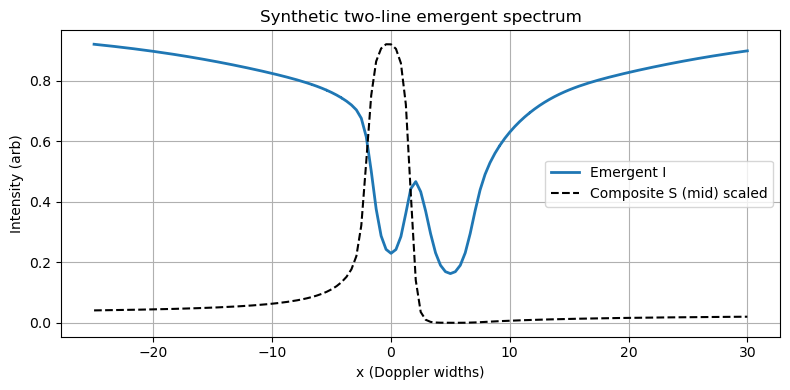

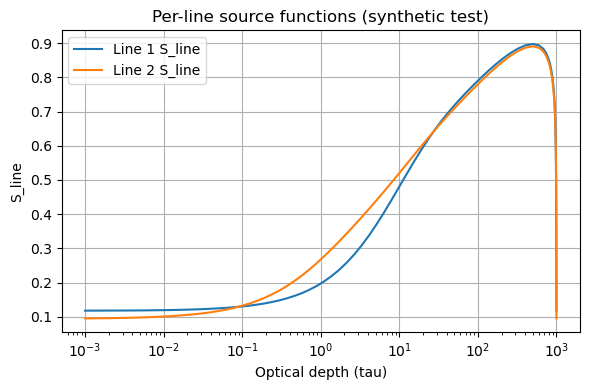

In [45]:
# Synthetic two-line test (quick validation)
# Creates a shallow slab and two lines with separated centers.
# Run the coupled solver and plot emergent intensity to check for two-line signatures.
import numpy as np
import matplotlib.pyplot as plt
import SLab_linev2 as v2

ND = 121
tau_max = 1e3
epsilon = np.ones(ND) * 1e-2
B = np.ones(ND) * 1.0
H = 1e5

slab_test = v2.Slab(ND, tau_max, epsilon, B, H)
# Two narrow lines centered at -2 and +2 Doppler widths
lineA = v2.Slab.Line(ND, line_center=0.0, a=0.05, k=1.0, slab_in=slab_test)
lineB = v2.Slab.Line(ND, line_center=5.0,  a=0.2, k=8.0, slab_in=slab_test)
lines_test = [lineA, lineB]

# Build a global x-grid and compute per-line profiles mapped to it
slab_test.global_x_grid(lines_test)
for L in lines_test:
    # compute_phi_x will populate L.phi_x and we normalize to slab.x_weights below if needed
    if hasattr(L, 'compute_phi_x'):
        L.compute_phi_x(slab_test.x_values)
    # normalize and expose phi_x_global for diagnostics
    if getattr(slab_test, 'x_weights', None) is None:
        dx = slab_test.x_values[1] - slab_test.x_values[0]
        slab_test.x_weights = np.ones_like(slab_test.x_values) * dx
    norm = np.sum(L.phi_x * slab_test.x_weights)
    L.phi_x_global = (L.phi_x / norm) if norm != 0.0 else L.phi_x.copy()

# Print phi normalization diagnostics
for i, L in enumerate(lines_test):
    print(f'Synthetic line {i+1} phi sum (phi*xw): {np.sum(L.phi_x_global * slab_test.x_weights):.8f}')

# Run the coupled iteration (short)
res = slab_test.iterate_coupled_lines(lines_test, max_iter=300, tol=1e-5, verbose=False)
S_nu = res['S_nu']
I_emergent = res['I_emergent']
S_lines = res['S_lines']

x = slab_test.x_values
tau = slab_test.tau

# Print some diagnostics about denom used in composite S
denom = np.zeros_like(x)
for L in lines_test:
    denom += L.k * L.phi_x_global
print('denom min, max:', np.min(denom), np.max(denom))

# Plot emergent intensity and composite S at mid depth (scaled)
plt.figure(figsize=(8,4))
plt.plot(x, I_emergent, lw=2, label='Emergent I')
mid = ND // 2
comp_mid = S_nu[mid, :]
comp_scaled = (comp_mid - np.min(comp_mid)) / (np.max(comp_mid) - np.min(comp_mid) + 1e-30)
plt.plot(x, comp_scaled * np.max(I_emergent), '--k', lw=1.5, label='Composite S (mid) scaled')
plt.xlabel('x (Doppler widths)')
plt.ylabel('Intensity (arb)')
plt.title('Synthetic two-line emergent spectrum')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Also show per-line S_line vs tau for sanity
plt.figure(figsize=(6,4))
for i, Sline in enumerate(S_lines):
    plt.plot(tau, Sline, label=f'Line {i+1} S_line')
plt.xlabel('Optical depth (tau)')
plt.ylabel('S_line')
plt.xscale('log')
plt.title('Per-line source functions (synthetic test)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Diagnostics for synthetic two-line test
Shapes: S_nu (121, 144) I_emergent (144,) len(S_lines) 2
denom min, max: 0.0005950210878952798 3.6693426095153754
line centers (requested): [0.0, 5.0]
center indices on global x grid: [67, 79]
--- Line 1 at x=0 (idx=67) ---
 S_nu top, mid, bottom: 0.11693107049448181 0.8970879439824755 0.11693107049927223
 S_line top, mid, bottom: 0.11782202789409853 0.8973510772922302 0.1178220278988986
 k * phi at center: 0.5343418332296416
 denom at center: 0.5561403160214358
--- Line 2 at x=5 (idx=79) ---
 S_nu top, mid, bottom: 0.09509542312182866 0.8906390540958505 0.09509542312638235
 S_line top, mid, bottom: 0.09509121059285945 0.890637809977231 0.09509121059741309
 k * phi at center: 3.6686625982410046
 denom at center: 3.6693426095153754
Approx tau(surface->mid) at center 0: 75.782
Approx tau(surface->mid) at center 5: 500
Line 1 S_line min,max = 0.117822, 0.897351, ratio max/min = 7.61616
Line 2 S_line min,max = 0.0950912, 0.890638, ratio max/min = 9.3

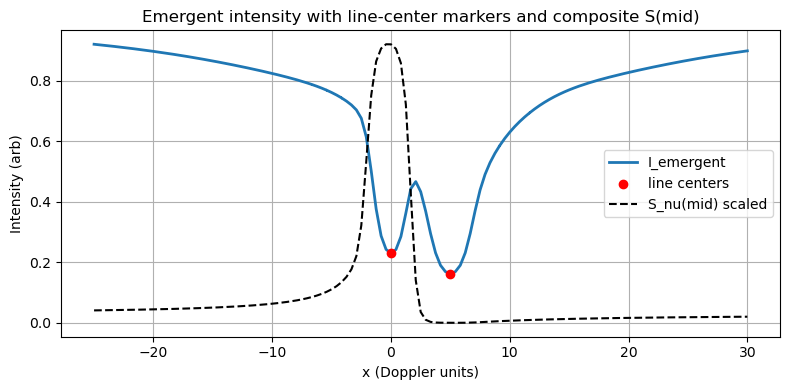

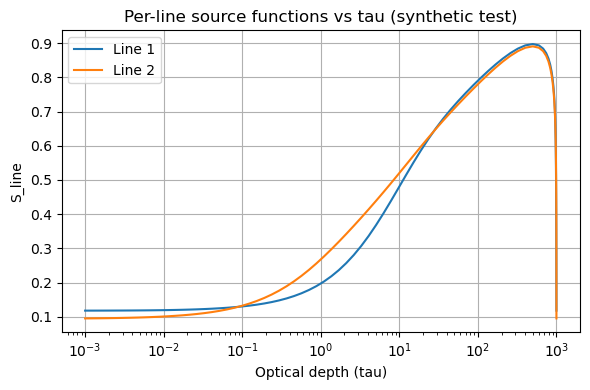

Diagnostic cell finished. If S_line is flat or S_nu(mid) is higher at line center than surface, the emergent I may not show a central reversal.Consider checking absolute scaling of line opacity relative to continuum or boundary conditions (illumination).


In [46]:
# Diagnostics: why is there no central minima in emergent intensity?
# Run this diagnostics cell after the synthetic two-line test (it expects variables from that cell to exist)
import numpy as np
import matplotlib.pyplot as plt

print('Diagnostics for synthetic two-line test')
# Expected variables: slab_test, lines_test, res, S_nu, I_emergent, S_lines, x, tau
try:
    print('Shapes: S_nu', np.shape(S_nu), 'I_emergent', np.shape(I_emergent), 'len(S_lines)', len(S_lines))
except Exception as _e:
    print('Required variables not found in namespace:', _e)
    raise

# Compute denom = sum_k k * phi(x) used in composite S construction
denom = np.zeros_like(x)
for L in lines_test:
    denom += L.k * L.phi_x_global
print('denom min, max:', float(np.min(denom)), float(np.max(denom)))

# Locate indices near each line center on the global x grid
centers = [L.line_center for L in lines_test]
center_idxs = [int(np.argmin(np.abs(x - c))) for c in centers]
print('line centers (requested):', centers)
print('center indices on global x grid:', center_idxs)

mid = int(slab_test.ND // 2)
for i, idx in enumerate(center_idxs):
    print(f'--- Line {i+1} at x={x[idx]:.6g} (idx={idx}) ---')
    print(' S_nu top, mid, bottom:', float(S_nu[0, idx]), float(S_nu[mid, idx]), float(S_nu[-1, idx]))
    if i < len(S_lines):
        Sline = np.asarray(S_lines[i])
        print(' S_line top, mid, bottom:', float(Sline[0]), float(Sline[mid]), float(Sline[-1]))
    print(' k * phi at center:', float(lines_test[i].k * lines_test[i].phi_x_global[idx]))
    print(' denom at center:', float(denom[idx]))

# Approximate monochromatic optical depth from surface to mid (scaled by denom)
# This is only a relative indicator when absolute line-to-continuum scaling is unknown.
tau_mid = float(slab_test.tau[mid])
tau_eff = tau_mid * (denom / (np.max(denom) + 1e-30))
for i, idx in enumerate(center_idxs):
    print(f'Approx tau(surface->mid) at center {x[idx]:.6g}: {float(tau_eff[idx]):.6g}')

# Quick sanity stats for S_line profiles
for i, Sline in enumerate(S_lines):
    Sline = np.asarray(Sline)
    smin = float(Sline.min())
    smax = float(Sline.max())
    print(f'Line {i+1} S_line min,max = {smin:.6g}, {smax:.6g}, ratio max/min = {smax/(smin+1e-30):.6g}')

# Plot emergent intensity and mark line centers; overlay composite S at mid (scaled)
plt.figure(figsize=(8,4))
plt.plot(x, I_emergent, lw=2, label='I_emergent')
plt.scatter([x[idx] for idx in center_idxs], [I_emergent[idx] for idx in center_idxs], color='red', zorder=5, label='line centers')
comp_mid = S_nu[mid, :]
comp_scaled = (comp_mid - np.min(comp_mid)) / (np.max(comp_mid) - np.min(comp_mid) + 1e-30)
plt.plot(x, comp_scaled * np.max(I_emergent), '--k', label='S_nu(mid) scaled')
plt.xlabel('x (Doppler units)')
plt.ylabel('Intensity (arb)')
plt.title('Emergent intensity with line-center markers and composite S(mid)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Plot per-line source functions vs tau (log-scaled x-axis for tau)
plt.figure(figsize=(6,4))
for i, Sline in enumerate(S_lines):
    plt.plot(tau, Sline, label=f'Line {i+1}')
plt.xlabel('Optical depth (tau)')
plt.xscale('log')
plt.ylabel('S_line')
plt.title('Per-line source functions vs tau (synthetic test)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print('Diagnostic cell finished. If S_line is flat or S_nu(mid) is higher at line center than surface, the emergent I may not show a central reversal.Consider checking absolute scaling of line opacity relative to continuum or boundary conditions (illumination).')